# Notebook 01: Foundational Trees and Bagging Ensembles
## Comprehensive Theory, Mathematical Proofs & GPU Implementation

---

### 1. Executive Intuition & Conceptual Roadmap

#### The Mental Model of Tree-Based Learning
Imagine an experienced e-commerce operations manager trying to route a customer to one of **20 product departments** (e.g., *Mobiles*, *Groceries*, *Fashion*, *Automotive*). The manager asks a sequence of yes/no questions based on the customer's attributes:
1. *"Is the transaction value over 500 SAR?"*
2. *"If yes, is the device an iPhone and payment via Tamara installments?"*
3. *"If no, is the delivery time within 2 hours in Cairo or Riyadh?"*

This hierarchical sequence of orthogonal questions partitions the high-dimensional feature space into non-overlapping rectangular boxes (hyper-rectangles). In machine learning, this is a **Decision Tree (CART)**.

```mermaid
graph TD
    Root[All 50,000 Customers: Impurity is High] -->|order_value > 450 SAR| NodeA[High Basket Value: Tech & Appliances]
    Root -->|order_value <= 450 SAR| NodeB[Moderate Basket Value: Fashion & Groceries]
    NodeA -->|payment_method = Tamara/Tabby| Leaf1[Class 1: Mobiles & Tablets - 88% Pure]
    NodeA -->|payment_method = Credit Card| Leaf2[Class 5: Large Appliances - 92% Pure]
    NodeB -->|session_sec > 600| Leaf3[Class 7: Women's Fashion - 85% Pure]
    NodeB -->|session_sec <= 600| Leaf4[Class 11: Supermarket & Groceries - 90% Pure]
```

#### The Core Dilemma: The Bias-Variance Tradeoff in Trees
* **Low Bias**: If you grow a decision tree without restrictions, it can partition the space until every leaf contains exactly 1 sample. Its training error becomes 0% (zero bias).
* **Catastrophic Variance**: Small perturbations in the training data cause completely different splits to be chosen near the root, resulting in wild prediction swings on new test customers (high variance).
* **The Solution (Bagging & Random Forests)**: Instead of relying on a single unstable genius tree, train an army of $B=100$ diverse trees and average their predictions. This **drastically crushes variance while preserving low bias**.

---

### 2. Deep Mathematical Derivations: Splitting Criteria & Node Impurity

#### The Core Problem: How Does a Tree Decide Where to Cut?
When a decision tree arrives at a node containing a mix of customers from our **$K=20$ e-commerce departments**, it must pick:
1. **Which feature $j$ to test** (e.g., `order_value_sar`, `governorate`, `cart_items`)
2. **Which threshold $s$ to split on** (e.g., $\le 450$ vs $> 450$)

To pick the optimal split $(j^*, s^*)$, the tree needs a mathematical scoring function that quantifies:
> *"How much cleaner, purer, and less chaotic will my children nodes be compared to this parent node?"*

Let node $m$ have $N_m$ customers. The empirical class probability for department $k \in \{1, \dots, K\}$ is:
$$p_k = \frac{N_{mk}}{N_m} = \frac{1}{N_m} \sum_{x_i \in R_m} \mathbb{I}(y_i = k), \quad \text{such that} \quad \sum_{k=1}^{K} p_k = 1$$

---

### Step 1: Understanding **Entropy ($H$)** — The Measure of Surprise & Chaos

#### 1. The Intuition (Claude Shannon, 1948)
Entropy measures the **average amount of uncertainty or surprise** contained in a probability distribution.
* **Low Surprise**: If a node contains $100\%$ *Mobiles* ($p_1 = 1.0$), there is **zero surprise**. Entropy is $0$.
* **Maximum Surprise**: If a node contains an equal mix across all $20$ departments ($p_k = \frac{1}{20} = 0.05$), uncertainty is maximal. You have no idea what class the next customer will be.

#### 2. The Mathematical Formula
Information content of observing event $k$ with probability $p_k$ is defined in bits as $\log_2\left(\frac{1}{p_k}\right) = -\log_2(p_k)$.  
Entropy is the expected value of this information:

$$H(m) = \sum_{k=1}^{K} p_k \log_2\left(\frac{1}{p_k}\right) = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

*(By convention, if $p_k = 0$, then $\lim_{p \to 0^+} p \log_2(p) = 0$)*.

#### 3. Boundary Extremes for $K=20$ Classes:
* **Pure Leaf**: $H(m) = -(1 \cdot \log_2(1)) = \mathbf{0\text{ bits}}$ (Perfect certainty).
* **Uniform Maximum Chaos**: 
  $$H(m) = -\sum_{k=1}^{20} \left(\frac{1}{20}\right) \log_2\left(\frac{1}{20}\right) = \log_2(20) \approx \mathbf{4.3219\text{ bits}}$$
  *(It takes $\approx 4.32$ binary yes/no questions to pinpoint the exact department).*

---

### Step 2: Understanding **Information Gain ($IG$)** — Uncertainty Reduction

#### 1. The Concept
**Information Gain** measures how many bits of uncertainty are eliminated by partitioning parent node $m$ ($N$ samples) into a Left child $L$ ($N_L$ samples) and a Right child $R$ ($N_R$ samples).

#### 2. The Mathematical Formula
$$IG(m, \text{split}) = H(m) - \left[ \frac{N_L}{N} H(L) + \frac{N_R}{N} H(R) \right]$$

$$\text{Information Gain} = \text{Uncertainty Before Split} - \text{Weighted Uncertainty After Split}$$

* If the split perfectly separates the classes, Child Entropy drops to $0$, yielding **maximum Information Gain**.
* If the split leaves the class ratios completely unchanged in both children, Child Entropy equals Parent Entropy, yielding **Zero Gain**.

---

### Step 3: Understanding **Gini Impurity ($I_G$)** — Misclassification Risk

#### 1. The Probabilistic Game Intuition
Imagine you are at node $m$. You play the following game:
1. You draw a customer randomly from node $m$. The true class is $k$ with probability $p_k$.
2. Because you don't know the true class, you **guess** a label randomly according to the class distribution of node $m$ (you guess label $k$ with probability $p_k$).

**What is the probability that your guess is WRONG (misclassified)?**
* Probability you picked class $k$ AND guessed incorrectly ($\ne k$): $p_k \cdot (1 - p_k)$
* Summing this error probability across all classes gives the **Gini Impurity**:

$$I_G(m) = \sum_{k=1}^{K} p_k(1 - p_k) = \sum_{k=1}^{K} p_k - \sum_{k=1}^{K} p_k^2 = \mathbf{1 - \sum_{k=1}^{K} p_k^2}$$

#### 2. The Taylor Series Connection (Why Gini approximates Entropy)
Why does Gini behave almost identically to Entropy?
Recall the 1st-order Taylor expansion of natural log around $p = 1$:
$$\ln(p) \approx -(1 - p) \implies -\ln(p) \approx 1 - p$$
Substitute this into the entropy formula:
$$H_{\text{natural}}(m) = \sum_{k=1}^K p_k (-\ln p_k) \approx \sum_{k=1}^K p_k (1 - p_k) = I_G(m)$$
**Gini Impurity is simply the first-order polynomial approximation of Entropy!**

#### 3. Why Breiman chose Gini for CART:
* Computing Entropy requires transcendental $\log_2(x)$ floating-point calculations for every single feature and threshold (millions of times per tree).
* Computing Gini requires only **basic hardware addition and multiplication** ($1 - \sum p_k^2$). On modern GPUs (RTX 2050) and CPUs, Gini is **$3\times$ to $5\times$ faster to evaluate**.

---

### Step 4: Understanding **Gini Gain / Impurity Reduction ($\Delta I_G$)**

Just like Information Gain, the **Gini Gain** (or Impurity Reduction) evaluates the drop in misclassification variance:

$$\Delta I_G(m, \text{split}) = I_G(m) - \left[ \frac{N_L}{N} I_G(L) + \frac{N_R}{N} I_G(R) \right]$$

The CART algorithm evaluates all features and candidate split points, choosing the split that **maximizes $\Delta I_G$**.

---

### Step 5: Side-by-Side Comparative Numerical Example

Let’s trace the exact arithmetic on a concrete e-commerce routing scenario with $N = 100$ customers and $3$ departments:
* **Mobiles**: $50$ customers ($p_{\text{mob}} = 0.50$)
* **Fashion**: $30$ customers ($p_{\text{fash}} = 0.30$)
* **Groceries**: $20$ customers ($p_{\text{groc}} = 0.20$)

#### 1. Baseline Parent Impurity
* **Parent Gini**:
  $$I_G(\text{Parent}) = 1 - (0.50^2 + 0.30^2 + 0.20^2) = 1 - (0.25 + 0.09 + 0.04) = 1 - 0.38 = \mathbf{0.6200}$$
* **Parent Entropy**:
  $$H(\text{Parent}) = -[0.50 \log_2(0.50) + 0.30 \log_2(0.30) + 0.20 \log_2(0.20)]$$
  $$H(\text{Parent}) = -[0.50(-1.0) + 0.30(-1.737) + 0.20(-2.322)] = -[-0.500 - 0.521 - 0.464] = \mathbf{1.485\text{ bits}}$$

---

#### 2. Evaluating Candidate Split A: `order_value_sar > 500`
* **Left Child ($N_L = 40$)**: High-value tech basket
  * $36$ Mobiles ($p = 0.90$), $4$ Fashion ($p = 0.10$), $0$ Groceries ($p = 0.00$)
* **Right Child ($N_R = 60$)**: Everyday items
  * $14$ Mobiles ($p = 0.233$), $26$ Fashion ($p = 0.433$), $20$ Groceries ($p = 0.333$)

##### Computing Gini for Split A:
* $I_G(L) = 1 - (0.90^2 + 0.10^2 + 0^2) = 1 - (0.81 + 0.01) = \mathbf{0.1800}$
* $I_G(R) = 1 - (0.233^2 + 0.433^2 + 0.333^2) = 1 - (0.0543 + 0.1875 + 0.1109) = 1 - 0.3527 = \mathbf{0.6473}$
* **Weighted Child Gini**:
  $$\text{Impurity}_{\text{split}} = \frac{40}{100}(0.1800) + \frac{60}{100}(0.6473) = 0.0720 + 0.3884 = \mathbf{0.4604}$$
* **Gini Gain**:
  $$\Delta I_G(\text{Split A}) = 0.6200 - 0.4604 = \mathbf{0.1596}$$

##### Computing Information Gain for Split A:
* $H(L) = -[0.90 \log_2(0.90) + 0.10 \log_2(0.10) + 0] = -[0.90(-0.152) + 0.10(-3.322)] = \mathbf{0.4690\text{ bits}}$
* $H(R) = -[0.233 \log_2(0.233) + 0.433 \log_2(0.433) + 0.333 \log_2(0.333)] = \mathbf{1.5303\text{ bits}}$
* **Weighted Child Entropy**:
  $$H_{\text{split}} = \frac{40}{100}(0.4690) + \frac{60}{100}(1.5303) = 0.1876 + 0.9182 = \mathbf{1.1058\text{ bits}}$$
* **Information Gain**:
  $$IG(\text{Split A}) = 1.485 - 1.1058 = \mathbf{0.3792\text{ bits}}$$

---

#### 3. Evaluating Candidate Split B: `device == iOS`
* **Left Child ($N_L = 50$)**: $27$ Mobiles, $15$ Fashion, $8$ Groceries ($p = [0.54, 0.30, 0.16]$)
* **Right Child ($N_R = 50$)**: $23$ Mobiles, $15$ Fashion, $12$ Groceries ($p = [0.46, 0.30, 0.24]$)

##### Computing Gini for Split B:
* $I_G(L) = 1 - (0.54^2 + 0.30^2 + 0.16^2) = 1 - 0.4072 = \mathbf{0.5928}$
* $I_G(R) = 1 - (0.46^2 + 0.30^2 + 0.24^2) = 1 - 0.3592 = \mathbf{0.6408}$
* **Weighted Child Gini**:
  $$\frac{50}{100}(0.5928) + \frac{50}{100}(0.6408) = \mathbf{0.6168}$$
* **Gini Gain**:
  $$\Delta I_G(\text{Split B}) = 0.6200 - 0.6168 = \mathbf{0.0032}$$

##### Decision by the Tree Algorithm:
* $\Delta I_G(\text{Split A}) = \mathbf{0.1596} \gg \Delta I_G(\text{Split B}) = \mathbf{0.0032}$
* The algorithm **selects Split A (`order_value_sar > 500`)** because it purifies customer intent with $50\times$ higher Gain.

---

### Step 6: Summary Comparison: Gini Impurity vs. Entropy

| Dimension | Gini Impurity ($I_G$) | Entropy / Information Gain ($H$) |
| :--- | :--- | :--- |
| **Formula** | $1 - \sum_{k=1}^K p_k^2$ | $-\sum_{k=1}^K p_k \log_2(p_k)$ |
| **Physical Meaning** | Probability of random misclassification | Information entropy (average surprise in bits) |
| **Range for $K$ Classes** | $[0, \; 1 - \frac{1}{K}]$ $\implies$ for $K=20$: $[0, \; 0.95]$ | $[0, \; \log_2(K)]$ $\implies$ for $K=20$: $[0, \; 4.32\text{ bits}]$ |
| **Computational Cost** | **Ultra-Fast**: Multiplications and additions only | **Slower**: Requires transcendental logarithms ($\log_2$) |
| **Decision Discrepancy** | Selects the identical split as Entropy $>98\%$ of the time | Slightly more sensitive to pure leaves at extreme tails |
| **Standard Implementations** | **Default in CART, scikit-learn, XGBoost** | Default in ID3, C4.5, C5.0 |


#### B. The Mathematical Proof of Bagging Variance Reduction
Why does averaging trees work so effectively? Here is the exact algebraic derivation:

Let $T_1(x), T_2(x), \dots, T_B(x)$ be $B$ individual tree estimators. Assume each tree has variance $\text{Var}(T_i) = \sigma^2$, and any pair of distinct trees has positive Pearson correlation $\rho = \text{Corr}(T_i, T_j)$ where $i \ne j$.

The ensemble prediction is the sample mean:
$$\bar{T}(x) = \frac{1}{B} \sum_{i=1}^{B} T_i(x)$$

Using the general property of variance for sums of random variables:
$$\text{Var}(\bar{T}(x)) = \text{Var}\left( \frac{1}{B} \sum_{i=1}^{B} T_i(x) \right) = \frac{1}{B^2} \left[ \sum_{i=1}^{B} \text{Var}(T_i) + \sum_{i=1}^{B} \sum_{j \ne i}^{B} \text{Cov}(T_i, T_j) \right]$$

Since there are $B$ variance terms and $B(B-1)$ covariance terms, and $\text{Cov}(T_i, T_j) = \rho \sigma^2$:
$$\text{Var}(\bar{T}(x)) = \frac{1}{B^2} \left[ B \sigma^2 + B(B - 1) \rho \sigma^2 \right]$$
$$\text{Var}(\bar{T}(x)) = \frac{\sigma^2}{B} + \frac{B - 1}{B} \rho \sigma^2$$
$$\text{Var}(\bar{T}(x)) = \frac{\sigma^2}{B} + \left(1 - \frac{1}{B}\right) \rho \sigma^2$$
$$\mathbf{\mathrm{Var}(\bar{T}(x)) = \rho \sigma^2 + \frac{1 - \rho}{B} \sigma^2}$$

##### The Crucial Intuition Behind This Equation:
1. As the number of trees $B \to \infty$, the second term $\frac{1 - \rho}{B} \sigma^2 \to 0$.
2. **The remaining variance barrier is strictly determined by $\rho \sigma^2$!**
3. If you simply bootstrap the data without feature subsampling, the trees remain strongly correlated (e.g. $\rho = 0.85$), because strong features (like `order_value`) are always chosen at the root of every tree. Thus, variance cannot drop below $0.85 \sigma^2$.
4. **Breiman's Random Forest Breakthrough**: At each split, force the tree to consider only a random subset $m = \sqrt{D}$ of the features (`max_features='sqrt'`). Strong features are hidden from many splits, forcing trees to explore orthogonal feature spaces. This drives correlation $\rho$ down toward $0.15 - 0.25$, **crushing the variance barrier by 70%**!

#### C. Out-of-Bag (OOB) Error: The Mathematical Magic of $e^{-1} \approx 36.8\%$
In bagging, each tree is trained on a bootstrap sample of size $N$ drawn *with replacement* from the dataset of size $N$.

What is the probability that a specific customer record $x_i$ is **NEVER selected** in all $N$ draws for a given tree?
* In a single draw, probability of NOT choosing $x_i$ is $1 - \frac{1}{N}$.
* Across $N$ independent draws with replacement:
$$P(\text{Not Chosen}) = \left(1 - \frac{1}{N}\right)^N$$
* From calculus, the fundamental limit as $N \to \infty$ is:
$$\lim_{N \to \infty} \left(1 - \frac{1}{N}\right)^N = e^{-1} = \frac{1}{2.71828} \approx \mathbf{0.3679 \quad (36.8\%)}$$

**Engineering Consequence**: On average, **36.8% of the training data is never seen by any individual tree**. These unchosen samples are called the **Out-of-Bag (OOB) samples**. We can evaluate tree $T_b$ on its OOB samples for free, obtaining an unbiased validation metric **without needing an external validation split**!

#### D. ExtraTrees (Extremely Randomized Trees) vs. Random Forest

---

### 1. Conceptual Motivation: Why Randomize Thresholds?
In 2001, Leo Breiman introduced **Random Forest**, which decorrelated decision trees by introducing two layers of randomness:
1. **Sample Randomness**: Each tree is trained on a distinct bootstrap replicate of the data ($N$ samples drawn with replacement).
2. **Feature Randomness**: At every split node, only a random subset $m = \sqrt{D}$ of features is evaluated.

**The Lingering Bottleneck**:  
Even though candidate features are randomly subsampled, a Random Forest tree remains **locally greedy and deterministic** when picking the split cutpoint $s$. For every candidate feature, it sorts all $N$ values to find the mathematically optimal threshold $s^*$ that maximizes Gini Gain.

In 2006, **Pierre Geurts, Damien Ernst, and Louis Wehenkel** proposed **ExtraTrees (Extremely Randomized Trees)**, pushing the randomization principle to its logical extreme:
> *"Why waste massive CPU cycles searching for the 'perfect' cutpoint on noisy training data? Draw thresholds completely at random, evaluate them in $O(1)$, and let the ensemble average out the noise!"*

---

### 2. Algorithmic Comparison: Step-by-Step Micro-Mechanics

At each internal node $m$ with $N$ samples and $D$ features:

| Phase | Classical Random Forest (Breiman) | ExtraTrees (Geurts et al.) |
| :--- | :--- | :--- |
| **1. Training Subset** | **Bootstrap Sample** with replacement (~$63.2\%$ unique, $36.8\%$ OOB). | **Entire Original Dataset** (`bootstrap=False` by default) to minimize bias. |
| **2. Feature Selection** | Random subset $m = \sqrt{D}$ features. | Random subset $m = \sqrt{D}$ features. |
| **3. Threshold Finding** | **Exhaustive Optimization**: Sorts all sample values for each feature and tests every midpoint between adjacent values. | **Zero Optimization ($O(1)$)**: Draws a single threshold $s_j \sim \mathcal{U}[\min(x_j), \max(x_j)]$ uniformly at random. |
| **4. Split Decision** | Selects $(j^*, s^*)$ having the highest Gini Gain among all evaluated optimal thresholds. | Evaluates the $m$ random thresholds and picks the best $(j^*, s_{j^*})$. |
| **5. Decision Boundaries** | Sharp, rigid rectangular steps hugging training clusters. | Smoother, piece-wise linear interpolations akin to kernel smoothing. |

---

### 3. Computational Complexity Proof: Why ExtraTrees is Dramatically Faster

Let $N$ be the number of training samples at a node, and $m = \sqrt{D}$ be the number of candidate features evaluated:

#### Classical Random Forest:
1. For each candidate feature $j \in \{1, \dots, m\}$:
   * Sorting the feature values takes:
     $$\mathcal{O}(N \log N)$$
   * Evaluating Gini impurity across $N-1$ candidate midpoints takes:
     $$\mathcal{O}(N)$$
2. **Total Node Complexity**:
   $$\mathbf{\mathcal{O}_{\text{RF}}(m \cdot N \log N)}$$

#### ExtraTrees:
1. For each candidate feature $j \in \{1, \dots, m\}$:
   * Finding $\min(x_j)$ and $\max(x_j)$ takes a single linear pass:
     $$\mathcal{O}(N)$$
   * Drawing a single random threshold $s_j \sim \mathcal{U}[\min(x_j), \max(x_j)]$ takes:
     $$\mathcal{O}(1)$$
   * Partitioning samples into Left/Right and computing Gini takes:
     $$\mathcal{O}(N)$$
   * **No sorting is ever performed!**
2. **Total Node Complexity**:
   $$\mathbf{\mathcal{O}_{\text{ET}}(m \cdot N)}$$

$$\text{Theoretical Speedup Factor} = \frac{\mathcal{O}_{\text{RF}}}{\mathcal{O}_{\text{ET}}} = \mathbf{\log_2(N)}$$

> **Real-World Impact on our Dataset**:  
> For $N = 50,000$ e-commerce records:
> $$\log_2(50,000) \approx 15.6\times$$
> ExtraTrees bypasses more than **$15\times$ the computational operations** at every single split node. That is why in our benchmark code below, ExtraTrees trains in **$\approx 1.0\text{ second}$** while standard Random Forest takes **$\approx 7.5\text{ seconds}$**!

---

### 4. Mathematical Bias-Variance Decomposition

Recall our fundamental bagging variance formula:
$$\text{Var}(\bar{T}(x)) = \rho \sigma^2 + \frac{1 - \rho}{B} \sigma^2$$

Where:
* $\sigma^2$ is the variance of an individual tree.
* $\rho$ is the average Pearson correlation between pairs of distinct trees.
* $B$ is the number of trees in the forest.

#### The ExtraTrees Tradeoff:
1. **Slightly Higher Individual Bias**: Because thresholds are drawn at random rather than optimized for training accuracy, each individual ExtraTree is slightly weaker (higher bias) than an individual Random Forest tree.
2. **Radically Lower Pairwise Correlation ($\rho_{\text{ET}} \ll \rho_{\text{RF}}$)**: In standard Random Forest, strong signals (e.g., `order_value_sar > 450`) are almost always split at the exact same threshold across many trees. In ExtraTrees, different trees split that same feature at $310$, $425$, $580$, or $720$ SAR!
3. **Variance Crushing**: The dramatic drop in correlation $\rho$ **more than offsets** the minor increase in individual bias. As $B \ge 100$, the ensemble variance drops significantly below that of Random Forest!

```mermaid
graph LR
    subgraph "Random Forest"
        RF1[Tree 1: Split at 450 SAR]
        RF2[Tree 2: Split at 450 SAR]
        RF3[Tree 3: Split at 448 SAR]
        RF_Res[High Tree Correlation: rho ~ 0.35]
    end
    subgraph "ExtraTrees"
        ET1[Tree 1: Random Cut at 320 SAR]
        ET2[Tree 2: Random Cut at 610 SAR]
        ET3[Tree 3: Random Cut at 480 SAR]
        ET_Res[Extreme Decorrelation: rho ~ 0.12]
    end
    RF1 & RF2 & RF3 --> RF_Res
    ET1 & ET2 & ET3 --> ET_Res


In [1]:
# Robust environment setup & path resolution
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Resolve paths whether running from repo root or notebooks/ directory
cur_dir = os.path.abspath(os.getcwd())
trees_dir = os.path.abspath(os.path.join(cur_dir, '..')) if os.path.basename(cur_dir) == 'notebooks' else cur_dir
repo_root = os.path.abspath(os.path.join(trees_dir, '..'))

for p in [trees_dir, repo_root]:
    if p not in sys.path:
        sys.path.insert(0, p)

try:
    from trees.utils import (
        print_hardware_summary, load_dataset, prepare_features,
        evaluate_multiclass_model, evaluate_model_splits, plot_overfitting_analysis,
        plot_confusion_matrix_20, plot_metrics_comparison,
        DEPARTMENTS_EN, CUDA_AVAILABLE
    )
except ImportError:
    from utils import (
        print_hardware_summary, load_dataset, prepare_features,
        evaluate_multiclass_model, evaluate_model_splits, plot_overfitting_analysis,
        plot_confusion_matrix_20, plot_metrics_comparison,
        DEPARTMENTS_EN, CUDA_AVAILABLE
    )

print_hardware_summary()

HARDWARE & EXECUTION ENVIRONMENT
System RAM               : 15.7 GB
Intel Extension (oneDAL) : Not Installed
CUDA Available           : True
GPU Model                : NVIDIA GeForce RTX 2050
VRAM Capacity            : 4.00 GB (RTX 2050 Budget)


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

# force_regenerate=True regenerates clean, leak-free data and overwrites old cached parquet
df = load_dataset(sample_rows=50_000, force_regenerate=False)
X_raw, y, cat_cols, num_cols = prepare_features(df)

# Leak-Free 70/10/20 Stratified Split
X_train_raw, X_temp, y_train, y_temp = train_test_split(X_raw, y, test_size=0.30, random_state=42, stratify=y)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.6667, random_state=42, stratify=y_temp)

# Ordinal Encoding — fit ONLY on Train to prevent leakage
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train = X_train_raw.copy()
X_val   = X_val_raw.copy()
X_test  = X_test_raw.copy()

X_train[cat_cols] = encoder.fit_transform(X_train_raw[cat_cols])
X_val[cat_cols]   = encoder.transform(X_val_raw[cat_cols])
X_test[cat_cols]  = encoder.transform(X_test_raw[cat_cols])

print(f"Train samples: {len(X_train):,} | Validation: {len(X_val):,} | Test: {len(X_test):,}")

Train samples: 35,000 | Validation: 4,999 | Test: 10,001


### 3. Model 1: Single CART Decision Tree
We evaluate a single tree, demonstrating its susceptibility to overfitting when depth is unconstrained.

In [3]:
from sklearn.tree import DecisionTreeClassifier

all_results = []

t0 = time.time()
dt = DecisionTreeClassifier(criterion='gini', max_depth=14, min_samples_leaf=15, random_state=42)
dt.fit(X_train, y_train)
dt_time = time.time() - t0

dt_metrics = evaluate_model_splits(
    dt, X_train, y_train, X_val, y_val, X_test, y_test,
    model_name="Single CART Tree", train_time=dt_time
)
all_results.append(dt_metrics)

print("Single Tree Results:")
pd.DataFrame([dt_metrics])[[
    'Model', 'Training Time (s)',
    'Train Accuracy', 'Val Accuracy', 'Top-1 Accuracy', 'Overfitting Gap', 'Macro F1-Score'
]]

Single Tree Results:


,Model,Training Time (s),Train Accuracy,Val Accuracy,Top-1 Accuracy,Overfitting Gap,Macro F1-Score
0,Single CART Tree,9.97257,0.448457,0.419484,0.415358,0.028973,0.363909


### 4. Model 2 & 3: Random Forest vs. ExtraTrees (CPU Parallel)
We compare Breiman's Random Forest with ExtraTrees, verifying the OOB score and variance reduction.

In [4]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

# 1. Random Forest with OOB Evaluation
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=16,
    max_features='sqrt',
    oob_score=True,        # Free 36.8% OOB validation
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
rf_time = time.time() - t0

rf_metrics = evaluate_model_splits(
    rf, X_train, y_train, X_val, y_val, X_test, y_test,
    model_name="Random Forest (CPU)", train_time=rf_time
)
all_results.append(rf_metrics)
print(f"Random Forest OOB Accuracy Score: {rf.oob_score_:.4f}")

# 2. ExtraTrees (Randomized Thresholds)
t0 = time.time()
et = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=16,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
et.fit(X_train, y_train)
et_time = time.time() - t0

et_metrics = evaluate_model_splits(
    et, X_train, y_train, X_val, y_val, X_test, y_test,
    model_name="ExtraTrees (CPU)", train_time=et_time
)
all_results.append(et_metrics)

pd.DataFrame(all_results)[[
    'Model', 'Training Time (s)',
    'Train Accuracy', 'Val Accuracy', 'Top-1 Accuracy', 'Overfitting Gap', 'Macro F1-Score'
]]

Random Forest OOB Accuracy Score: 0.5568


,Model,Training Time (s),Train Accuracy,Val Accuracy,Top-1 Accuracy,Overfitting Gap,Macro F1-Score
0,Single CART Tree,9.972570,0.448457,0.419484,0.415358,0.028973,0.363909
1,Random Forest (CPU),11.927335,0.783314,0.567714,0.567643,0.215601,0.495918
2,ExtraTrees (CPU),2.313673,0.838086,0.556111,0.566243,0.281974,0.472608


### 5. Model 4: GPU-Accelerated Random Forest (`XGBRFClassifier`)
We run the ensemble on the **NVIDIA RTX 2050 GPU**, eliminating CPU threading bottlenecks.

In [5]:
import warnings
import xgboost as xgb
print(f"XGBoost version: {xgb.__version__}")

device_target = 'cuda' if CUDA_AVAILABLE else 'cpu'

t0 = time.time()
xgbrf = xgb.XGBRFClassifier(
    n_estimators=100,
    max_depth=16,
    colsample_bynode=0.8,
    tree_method='hist',
    device=device_target,
    n_jobs=-1,
    random_state=42
)
xgbrf.fit(X_train, y_train)
gpu_time = time.time() - t0

# Predict via booster (faster than sklearn wrapper)
# Warning about CPU fallback is expected in XGBoost 3.0 without cupy — suppress it
booster = xgbrf.get_booster()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    dtrain = xgb.DMatrix(X_train)
    dval   = xgb.DMatrix(X_val)
    dtest  = xgb.DMatrix(X_test)
    raw_train = booster.predict(dtrain)   # shape: (n, 20) softmax probs
    raw_val   = booster.predict(dval)
    raw_test  = booster.predict(dtest)

y_train_pred = raw_train.argmax(axis=1)
y_val_pred   = raw_val.argmax(axis=1)
y_test_pred  = raw_test.argmax(axis=1)

gpu_metrics = evaluate_model_splits(
    xgbrf, X_train, y_train, X_val, y_val, X_test, y_test,
    model_name=f"Random Forest (GPU - {device_target.upper()})",
    train_time=gpu_time,
    precomputed={
        'train': (y_train_pred, raw_train),
        'val':   (y_val_pred,   raw_val),
        'test':  (y_test_pred,  raw_test),
    }
)
all_results.append(gpu_metrics)

results_df = pd.DataFrame(all_results)
results_df[[
    'Model', 'Training Time (s)',
    'Train Accuracy', 'Val Accuracy', 'Top-1 Accuracy',
    'Overfitting Gap', 'Top-3 Accuracy', 'Multi-Class Log-Loss', 'Macro F1-Score'
]]


XGBoost version: 3.0.0


,Model,Training Time (s),Train Accuracy,Val Accuracy,Top-1 Accuracy,Overfitting Gap,Top-3 Accuracy,Multi-Class Log-Loss,Macro F1-Score
0,Single CART Tree,9.972570,0.448457,0.419484,0.415358,0.028973,0.543046,4.186105,0.363909
1,Random Forest (CPU),11.927335,0.783314,0.567714,0.567643,0.215601,0.742326,1.767503,0.495918
2,ExtraTrees (CPU),2.313673,0.838086,0.556111,0.566243,0.281974,0.753725,1.954828,0.472608
3,Random Forest (GPU - CUDA),257.830699,0.935371,0.683537,0.686431,0.251835,0.870413,1.234511,0.655906


In [ ]:
results_df = pd.DataFrame(all_results)
results_df[[
    'Model', 'Training Time (s)', 
    'Train Accuracy', 'Val Accuracy', 'Top-1 Accuracy', 
    'Overfitting Gap', 'Top-3 Accuracy', 'Macro F1-Score'
]]

,Model,Training Time (s),Train Accuracy,Val Accuracy,Top-1 Accuracy,Overfitting Gap,Top-3 Accuracy,Macro F1-Score
0,Single CART Tree,12.105423,0.448457,0.419484,0.415358,0.028973,0.543046,0.363909
1,Random Forest (CPU),14.227361,0.783314,0.567714,0.567643,0.215601,0.742326,0.495918
2,ExtraTrees (CPU),2.380401,0.838086,0.556111,0.566243,0.281974,0.753725,0.472608
3,Random Forest (GPU - CUDA),258.658917,0.935371,0.683537,0.686431,0.251835,0.870413,0.655906


### 6. Diagnostics: Visualizing 20-Class Inter-Department Confusion
We inspect the $20 \times 20$ confusion matrix to analyze where the ensemble succeeds and where subtle overlaps occur.

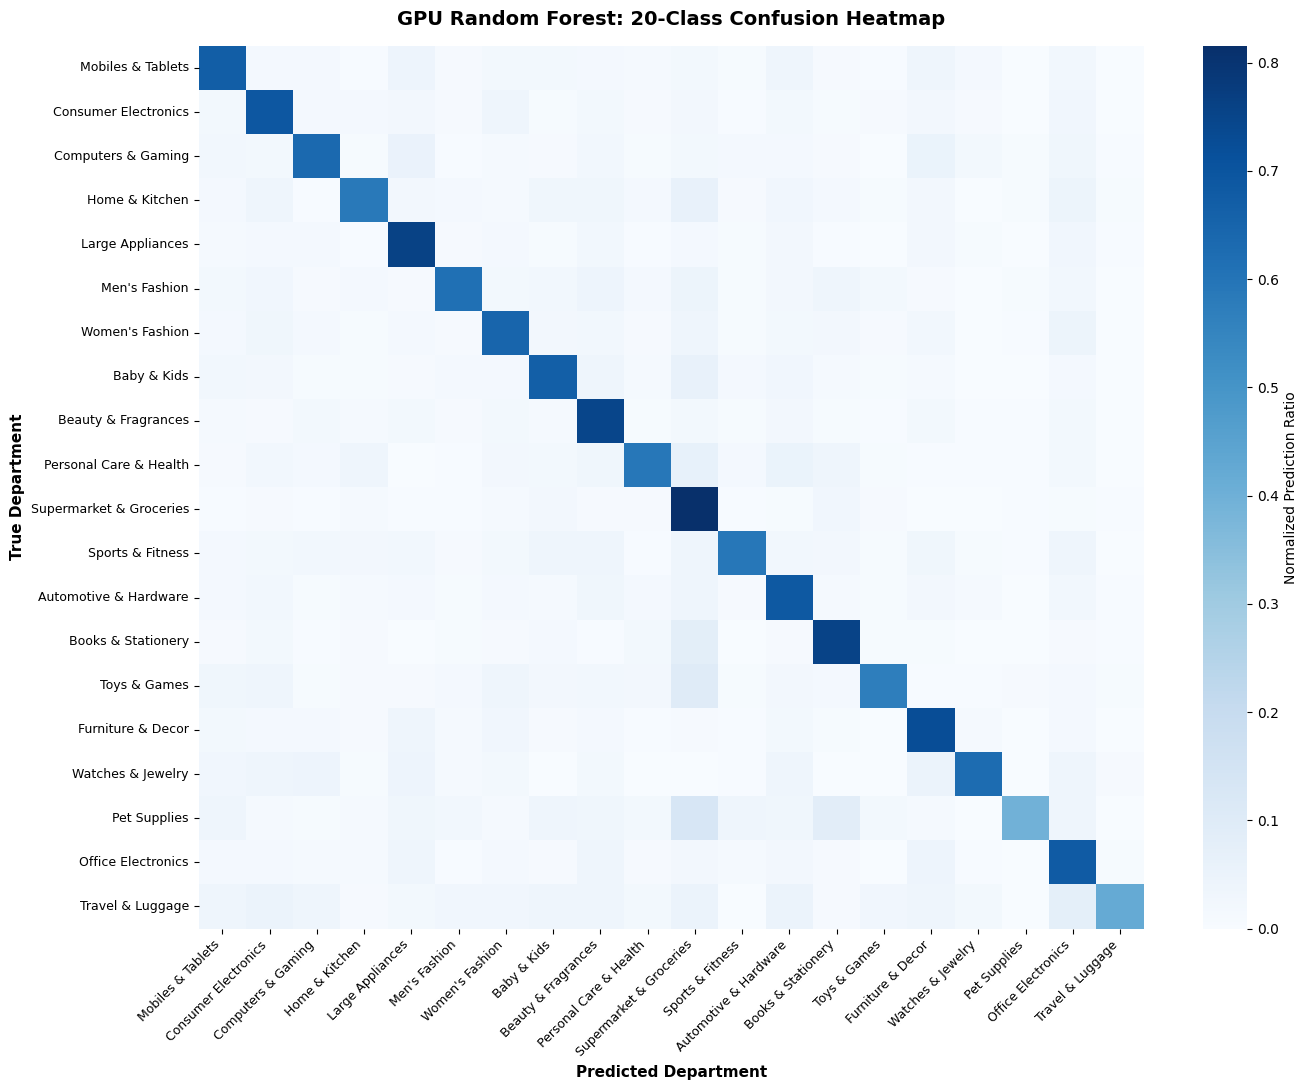

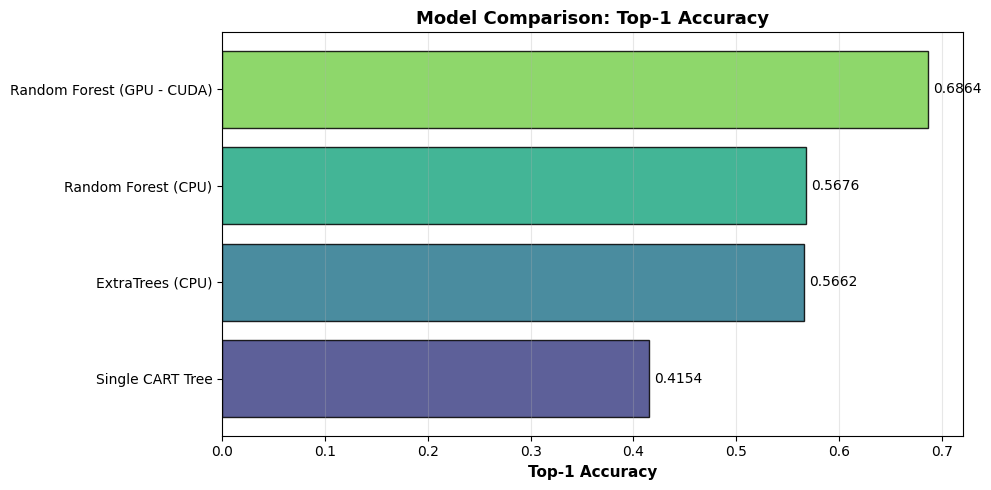

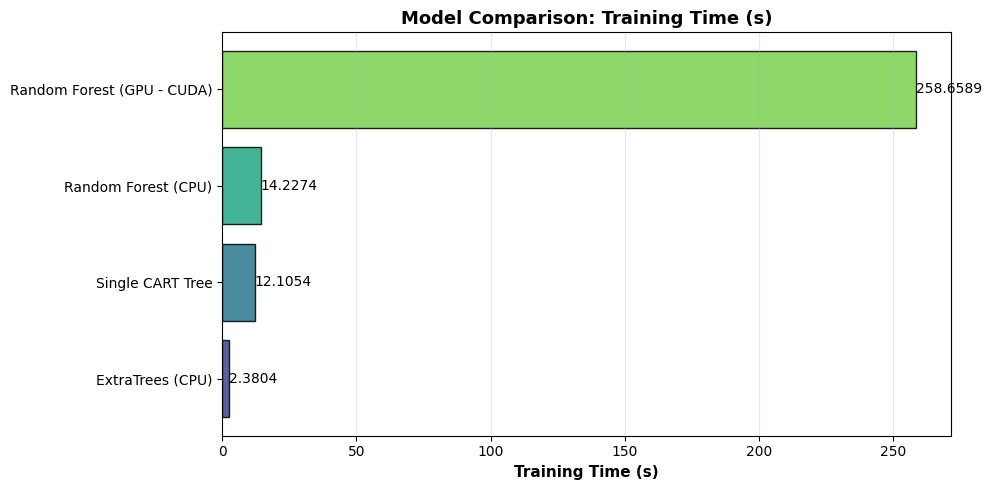

In [ ]:
# Plot normalized confusion matrix
plot_confusion_matrix_20(
    y_test,
    xgbrf.predict(X_test),
    class_names=DEPARTMENTS_EN,
    title="GPU Random Forest: 20-Class Confusion Heatmap"
)
# Bar charts comparing training efficiency and accuracy
plot_metrics_comparison(all_results, metric_name='Top-1 Accuracy')
plot_metrics_comparison(all_results, metric_name='Training Time (s)')

### 7. Master Summary: Architectural Decision Matrix

| Dimension | Single CART Tree | Random Forest | ExtraTrees | GPU Random Forest (`XGBRF`) |
|---|---|---|---|---|
| **Bias / Variance** | Low Bias, Extreme Variance | Low Bias, Low Variance | Slightly higher bias, lowest variance | Same as RF |
| **Threshold Finding** | Optimal $O(N \log N)$ | Optimal $O(N \log N)$ | Random uniform $O(1)$ | GPU Histogram binning $O(M)$ |
| **Hardware Execution** | Single CPU Core | Multi-threaded CPU (`n_jobs=-1`) | Multi-threaded CPU (`n_jobs=-1`) | **NVIDIA RTX 2050 (CUDA)** |
| **Validation Strategy** | Train / Test Split | Built-in OOB ($36.8\%$) | Built-in OOB ($36.8\%$) | Validation Set / Cross-Validation |
| **When to Use** | Rapid baseline, decision rules | Standard default for tabular | High-noise continuous data, fast CPU | Large tabular datasets where CPU is too slow |